# Cognifyz Intern Task 4: Location-Based Analysis

# Objective
## Perform a geographical analysis of the restaurants.

# Steps:
## Step 1: Import Libraries
## Step 2: Load Dataset
## Step 3: Data Cleaning
## Step 4: EDA (Exploratory Data Analysis)
## Step 5: Restaurant Distribution Map
## Step 6: Restaurant Concentration Analysis
## Step 7: Average Rating by City
## Step 8: Average Price Range by City
## Step 9: Popular Cuisine by City
## Step 10: Rating vs Location
## Step 11: Locality-Level Analysis

## Step 1: Import Libraries

In [32]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import folium
from folium.plugins import MarkerCluster

## Step 2: Load Dataset

In [33]:
lb = pd.read_csv(r"D:/Project/cognifyz_projects/dataset/restaurant.csv")

print(lb.shape)
lb.head()

(9551, 21)


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


## Step 3: Data Cleaning

In [34]:
lb.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [35]:
lb[['Latitude','Longitude']].isnull().sum()

Latitude     0
Longitude    0
dtype: int64

## Step 4: EDA (Exploratory Data Analysis)

In [37]:
print(lb['City'].nunique())

141


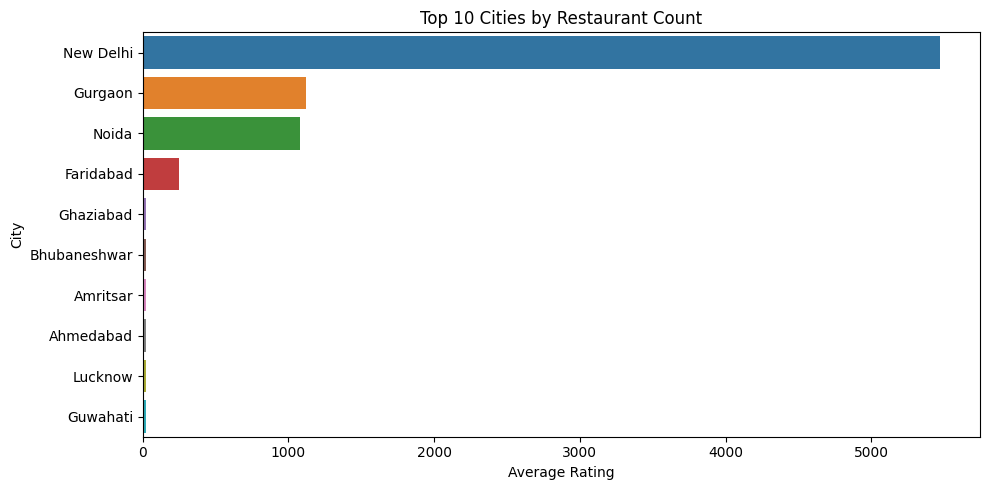

In [61]:
city_count = lb['City'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=city_count.values,
            y=city_count.index)

plt.title("Top 10 Cities by Restaurant Count")
plt.xlabel("Average Rating")
plt.ylabel("City")
plt.tight_layout()
plt.show()

## Step 5: Restaurant Distribution Map

In [57]:
restaurant_map = folium.Map(
    location=[lb['Latitude'].mean(),
              lb['Longitude'].mean()],
    zoom_start=5
)

for _, row in lb.head(500).iterrows():

    folium.CircleMarker(
        location=[row['Latitude'],
                  row['Longitude']],
        radius=3
    ).add_to(restaurant_map)

restaurant_map

In [ ]:
restaurant_map.save("D:/Project/cognifyz_projects/Task-4_Location-based_Analysis/map/restaurant_map.html")

## Step 6: Average Rating by City

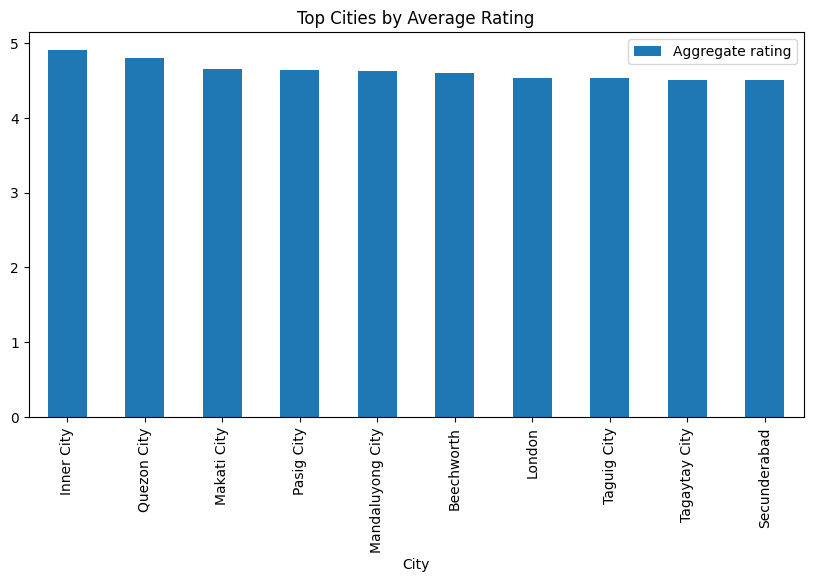

In [44]:
city_rating.head(10).to_frame().plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top Cities by Average Rating")
plt.show()

In [45]:
print(city_price.head(10))

City
Princeton           4.000000
Inner City          4.000000
Vineland Station    4.000000
Johannesburg        4.000000
Panchkula           4.000000
Pasay City          4.000000
Paynesville         4.000000
Sandton             3.818182
Mandaluyong City    3.750000
Pretoria            3.700000
Name: Price range, dtype: float64


## Step 7: Average Price Range by City

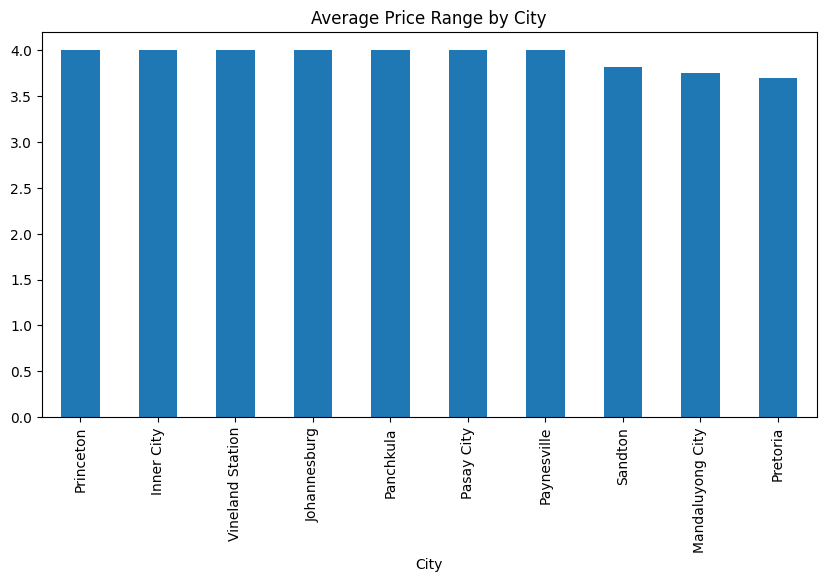

In [47]:
city_price.head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Average Price Range by City")
plt.show()

## Step 8: Popular Cuisine by City

In [48]:
popular_cuisine = (
    lb.groupby("City")["Cuisines"]
      .agg(lambda x: x.mode()[0]
           if len(x.mode()) > 0
           else "Unknown")
)

popular_cuisine.head(10)

City
Abu Dhabi                                            American
Agra                                    North Indian, Mughlai
Ahmedabad    Cafe, American, Continental, Armenian, Fast Food
Albany                                 Japanese, Steak, Sushi
Allahabad                               North Indian, Chinese
Amritsar                                         North Indian
Ankara                                   Kebab, Turkish Pizza
Armidale                                      Bar Food, Steak
Athens                               American, Italian, Pizza
Auckland                                                 Cafe
Name: Cuisines, dtype: object

## Step 9: Rating vs Location

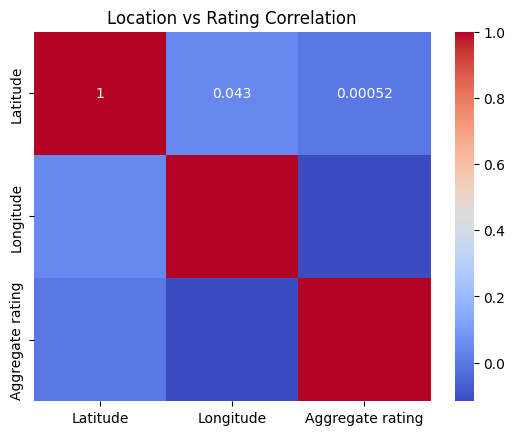

In [49]:
corr = lb[['Latitude',
           'Longitude',
           'Aggregate rating']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Location vs Rating Correlation")
plt.show()

## Step 10: Locality-Level Analysis

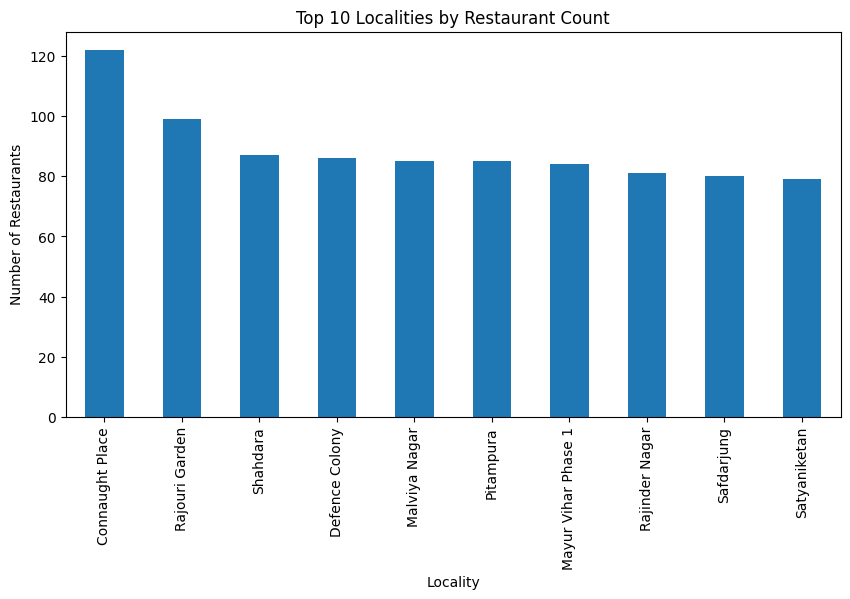

In [50]:
locality_count.head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 10 Localities by Restaurant Count")
plt.ylabel("Number of Restaurants")
plt.show()

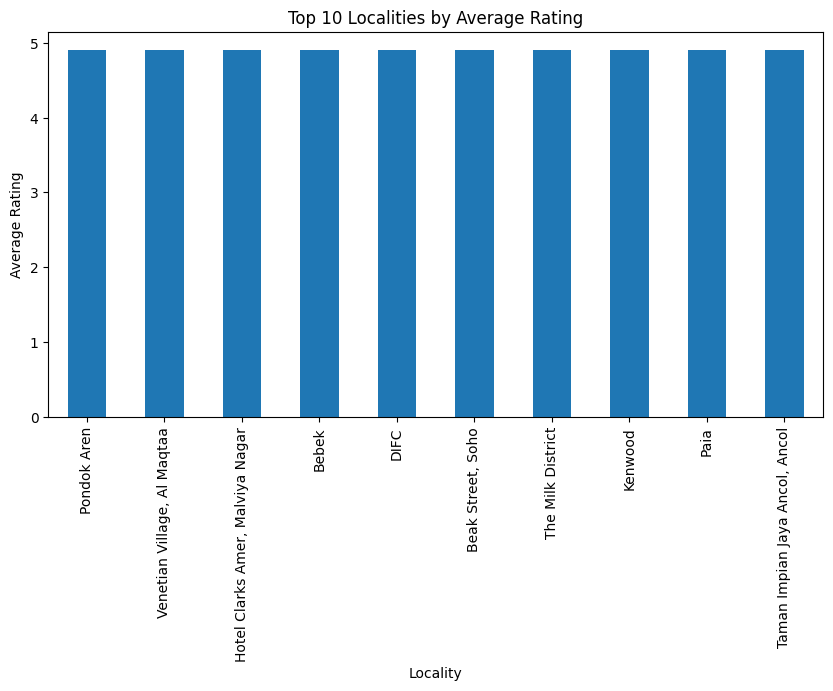

In [51]:
locality_rating.head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 10 Localities by Average Rating")
plt.ylabel("Average Rating")
plt.show()

# Key Insights

1. New Delhi has the highest concentration of restaurants.
2. Gurgaon and Noida follow New Delhi in restaurant density.
3. Latitude has almost no correlation with ratings.
4. Longitude shows a weak negative correlation with ratings.
5. Premium cities tend to have higher average price ranges.
6. Connaught Place is the most restaurant-dense locality.
7. Several localities maintain very high average ratings (~4.9).
8. Restaurant distribution is concentrated in major urban regions.

# Conclusion

This location-based analysis explored restaurant distribution using latitude and longitude coordinates. Major cities such as New Delhi, Gurgaon, and Noida contain the highest concentration of restaurants. Correlation analysis showed that geographical coordinates have little impact on restaurant ratings. Locality-level analysis identified restaurant hotspots and highly rated areas. These findings provide useful insights into restaurant density, customer preferences, and business opportunities across different locations.